In [ ]:


import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from torchvision import datasets, transforms, models

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

NUM_CLASSES = 10
BATCH_SIZE = 512
EPOCHS = 10
LR = 0.1

K_PROBES = 28   ### equal to input data size
EPSILON = 0.1
LAMBDA_JET = 0.1
ETA_JET = 0.5
NUM_WORKERS = 8
MAX_TRAIN_BATCHES = 0
ENERGY = 0.5

_cuda_env = os.getenv("CUDA_DEVICE")
if torch.cuda.is_available() and _cuda_env is not None:
    DEVICE = torch.device(f'cuda:{_cuda_env}')
else:
    DEVICE = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {DEVICE}")


def build_loaders(batch_size, num_workers=NUM_WORKERS):
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.1307,), (0.3081,))
    ])
    print("Loading MNIST dataset...")
    train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
    test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)
    train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=num_workers)
    test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers)
    print(f"Train samples: {len(train_dataset)}, Test samples: {len(test_dataset)}")
    return train_loader, test_loader

def baseline_resnet101(num_classes):
    model = models.resnet101(weights=None)
    model.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model


class MNISTClassifier2F(nn.Module):
    def __init__(self, num_classes, k_probes, epsilon):
        super().__init__()

        resnet_model = models.resnet101(weights=None)
        resnet_model.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)

        self.stem1 = nn.Sequential(
            resnet_model.conv1,
            resnet_model.bn1,
            resnet_model.relu,
            resnet_model.maxpool,
            resnet_model.layer1,
        )
        self.layer2 = resnet_model.layer2
        self.layer3 = resnet_model.layer3
        self.layer4 = resnet_model.layer4
        self.avgpool = resnet_model.avgpool

        self.proj1 = nn.Sequential(nn.AdaptiveAvgPool2d((1, 1)), nn.Flatten(), nn.Linear(64, 1))
        self.proj2 = nn.Sequential(nn.AdaptiveAvgPool2d((1, 1)), nn.Flatten(), nn.Linear(128, 1))
        self.fc = nn.Linear(512 + 2, num_classes)

    @staticmethod
    def _feature_fisher(feature_map, projection):
        if not feature_map.requires_grad:
            feature_map.requires_grad_(True)
        energy = projection(feature_map).sum()
        grads = torch.autograd.grad(energy, feature_map, create_graph=True, retain_graph=True)[0]
        return grads.flatten(1).pow(2).mean(dim=1, keepdim=True)

    def forward(self, x):
        with torch.set_grad_enabled(True):
            h1 = self.stem1(x)
            h2 = self.layer2(h1)
            f1 = self._feature_fisher(h1, self.proj1)
            f2 = self._feature_fisher(h2, self.proj2)

        h = self.layer4(self.layer3(h2))
        pooled = self.avgpool(h).flatten(1)
        logits = self.fc(torch.cat([pooled, f1, f2], dim=1))
        return logits, (f1 + f2) / 2


class MNISTClassifier3F(nn.Module):
    def __init__(self, num_classes, k_probes, epsilon):
        super().__init__()

        resnet_model = models.resnet101(weights=None)
        resnet_model.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)

        self.stem1 = nn.Sequential(
            resnet_model.conv1,
            resnet_model.bn1,
            resnet_model.relu,
            resnet_model.maxpool,
            resnet_model.layer1,
        )
        self.layer2 = resnet_model.layer2
        self.layer3 = resnet_model.layer3
        self.layer4 = resnet_model.layer4
        self.avgpool = resnet_model.avgpool

        self.proj1 = nn.Sequential(nn.AdaptiveAvgPool2d((1, 1)), nn.Flatten(), nn.Linear(64, 1))
        self.proj2 = nn.Sequential(nn.AdaptiveAvgPool2d((1, 1)), nn.Flatten(), nn.Linear(128, 1))
        self.proj3 = nn.Sequential(nn.AdaptiveAvgPool2d((1, 1)), nn.Flatten(), nn.Linear(256, 1))
        self.fc = nn.Linear(512 + 3, num_classes)

    @staticmethod
    def _feature_fisher(feature_map, projection):
        if not feature_map.requires_grad:
            feature_map.requires_grad_(True)
        energy = projection(feature_map).sum()
        grads = torch.autograd.grad(energy, feature_map, create_graph=True, retain_graph=True)[0]
        return grads.flatten(1).pow(2).mean(dim=1, keepdim=True)

    def forward(self, x):
        with torch.set_grad_enabled(True):
            h1 = self.stem1(x)
            h2 = self.layer2(h1)
            h3 = self.layer3(h2)
            f1 = self._feature_fisher(h1, self.proj1)
            f2 = self._feature_fisher(h2, self.proj2)
            f3 = self._feature_fisher(h3, self.proj3)

        h = self.layer4(h3)
        pooled = self.avgpool(h).flatten(1)
        logits = self.fc(torch.cat([pooled, f1, f2, f3], dim=1))
        return logits, (f1 + f2 + f3) / 3


class MNISTClassifierAllF(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        backbone = models.resnet101(weights=None)
        backbone.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)

        self.stem = nn.Sequential(
            backbone.conv1,
            backbone.bn1,
            backbone.relu,
            backbone.maxpool,
        )
        self.layer1 = backbone.layer1
        self.layer2 = backbone.layer2
        self.layer3 = backbone.layer3
        self.layer4 = backbone.layer4
        self.avgpool = backbone.avgpool

        self.feature_names = [
            "stem",
            "layer1_block0",
            "layer1_block1",
            "layer2_block0",
            "layer2_block1",
            "layer3_block0",
            "layer3_block1",
            "layer4_block0",
            "layer4_block1",
        ]

        channel_map = {
            "stem": 64,
            "layer1_block0": 64,
            "layer1_block1": 64,
            "layer2_block0": 128,
            "layer2_block1": 128,
            "layer3_block0": 256,
            "layer3_block1": 256,
            "layer4_block0": 512,
            "layer4_block1": 512,
        }

        self.fisher_heads = nn.ModuleDict({
            name: nn.Sequential(
                nn.AdaptiveAvgPool2d((1, 1)),
                nn.Flatten(),
                nn.Linear(channel_map[name], 1),
            )
            for name in self.feature_names
        })

        self.classifier = nn.Linear(512 + len(self.feature_names), num_classes)

    @staticmethod
    def _fisher_term(feature_map, projection_head):
        energy = projection_head(feature_map).sum()
        grads = torch.autograd.grad(
            outputs=energy,
            inputs=feature_map,
            create_graph=True,
            retain_graph=True,
        )[0]
        return grads.flatten(1).pow(2).mean(dim=1, keepdim=True)

    def _extract_backbone_features(self, x):
        features = {}

        h = self.stem(x)
        features["stem"] = h

        h = self.layer1[0](h)
        features["layer1_block0"] = h
        h = self.layer1[1](h)
        features["layer1_block1"] = h

        h = self.layer2[0](h)
        features["layer2_block0"] = h
        h = self.layer2[1](h)
        features["layer2_block1"] = h

        h = self.layer3[0](h)
        features["layer3_block0"] = h
        h = self.layer3[1](h)
        features["layer3_block1"] = h

        h = self.layer4[0](h)
        features["layer4_block0"] = h
        h = self.layer4[1](h)
        features["layer4_block1"] = h

        return features, h

    def forward(self, x):
        with torch.set_grad_enabled(True):
            if not x.requires_grad:
                x.requires_grad_(True)

            O0 = self.compute_local_fisher(x)

            mean_v = self.probes.mean(dim=0, keepdim=True)
            x_pos = x + self.epsilon * mean_v
            x_neg = x - self.epsilon * mean_v

            I_pos = self.compute_local_fisher(x_pos)
            I_neg = self.compute_local_fisher(x_neg)

            O1 = (I_pos - I_neg) / (2 * self.epsilon)
            O2 = (I_pos - 2 * O0 + I_neg) / (self.epsilon ** 2)

        _, h = self.get_energy_and_embedding(x)

        # Compute Fisher information between energy_net and conv_layer
        with torch.set_grad_enabled(True):
            fish_energy_net = self.compute_fisher_on_output(h, x)

        # Apply convolutional layers between energy_net and pred_net
        # Reshape h from [batch, hidden_dim] to [batch, 1, hidden_dim]
        h_conv = h.unsqueeze(1)
        h_conv = self.conv_layer(h_conv)  # Output: [batch, 32, hidden_dim]
        
        # Compute Fisher information between conv_layer and pred_net
        with torch.set_grad_enabled(True):
            fish_conv_layer = self.compute_fisher_on_output(h_conv, x)
        
        h_conv = h_conv.view(h_conv.size(0), -1)  # Flatten: [batch, 32*hidden_dim]
        
        features = torch.cat([h_conv, O0, O1, O2, fish_energy_net, fish_conv_layer], dim=1)
        y_hat = self.pred_net(features)

        return y_hat, O0 # Return O0 for viz/loss if needed


def evaluate(model, test_loader):
    model.eval()
    correct, total = 0, 0
    grad_required = hasattr(model, 'compute_score')
    context = torch.enable_grad() if grad_required else torch.no_grad()
    with context:
        for data, target in test_loader:
            data, target = data.to(DEVICE), target.to(DEVICE)
            logits = model(data)
            if isinstance(logits, tuple):
                logits = logits[0]
            _, predicted = torch.max(logits.data, 1)
            total += target.size(0)
            correct += (predicted == target).sum().item()
    return 100 * correct / total



def jet_regularizer(model, data):
    mean_v = model.probes.mean(dim=0, keepdim=True).view(1, 1, 28, 28)
    pred_pos, _ = model(data + EPSILON * mean_v)
    pred_neg, _ = model(data - EPSILON * mean_v)
    d_hat = (pred_pos - pred_neg) / (2 * EPSILON)
    score_proj = model.compute_score(data).mean(dim=1, keepdim=True)
    return ((d_hat + LAMBDA_JET * score_proj) ** 2).mean()


# Updated: accept optimizer instance (or string/None) and use it for training
def run_experiment(name, model, train_loader, test_loader, optimizer=None, loss_name='CrossEntropy', use_jet=False, log_every=50):
    model = model.to(DEVICE)

    # Loss selection
    if loss_name == 'MAE':
        criterion = nn.L1Loss()
    else:
        criterion = nn.CrossEntropyLoss()

    # If optimizer is a string or None, create optimizer for this model
    if isinstance(optimizer, str) or optimizer is None:
        opt_name = optimizer if isinstance(optimizer, str) else 'Adam'
        if opt_name == 'Adam':
            optimizer = optim.Adam(model.parameters(), lr=LR)
        elif opt_name == 'SGD':
            optimizer = optim.SGD(model.parameters(), lr=LR)
        elif opt_name == 'RMSprop':
            optimizer = optim.RMSprop(model.parameters(), lr=LR)
        else:
            raise ValueError(f"Unknown optimizer: {opt_name}")

    train_losses, test_accuracies = [], []

    jet_supported = hasattr(model, 'compute_score') and hasattr(model, 'probes')
    if use_jet and not jet_supported:
        print(f"[Info] Jet loss is not supported for {model.__class__.__name__}; running without Jet loss.")
        use_jet = False

    print(f"\n--- {name} ---")
    for epoch in range(EPOCHS):
        model.train()
        epoch_loss = 0.0
        for batch_idx, (data, target) in enumerate(train_loader):
            data, target = data.to(DEVICE), target.to(DEVICE)
            optimizer.zero_grad()
            y_hat = model(data)
            if not loss_name == 'MAE':
                loss = criterion(y_hat, target)
            else:
                loss = criterion(y_hat, target.view(-1, 1).float())
            if use_jet:
                loss = loss + ETA_JET * jet_regularizer(model, data)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()

            if batch_idx % log_every == 0:
                print(f"Epoch {epoch}, Batch {batch_idx}/{len(train_loader)}: Loss={loss.item():.4f}")

            if MAX_TRAIN_BATCHES > 0 and (batch_idx + 1) >= MAX_TRAIN_BATCHES:
                break

        avg_loss = epoch_loss / len(train_loader)
        acc = evaluate(model, test_loader)
        train_losses.append(avg_loss)
        test_accuracies.append(acc)
        print(f"Epoch {epoch} | Train Loss: {avg_loss:.4f} | Test Accuracy: {acc:.2f}%")

    print(f"Final Test Accuracy: {test_accuracies[-1]:.2f}%")
    return train_losses, test_accuracies



Using device: cuda:0


In [ ]:

if __name__ == "__main__":
    train_loader, test_loader = build_loaders(BATCH_SIZE, NUM_WORKERS)

    # For each model, create the model, create an optimizer bound to that model, then pass optimizer into run_experiment
    model = baseline_resnet101(NUM_CLASSES)
    optimizer = optim.Adam(model.parameters(), lr=LR)
    train_losses_baseline_adam_crossentropy, test_accuracies_baseline_adam_crossentropy = run_experiment(
        "Baseline ResNet101 (Adam + CrossEntropy)", model, train_loader, test_loader, optimizer=optimizer, use_jet=False, log_every=150
    )

    # Example additional runs with different optimizers for baseline model
    model = baseline_resnet101(NUM_CLASSES)
    optimizer = optim.SGD(model.parameters(), lr=LR)
    train_losses_baseline_sgd_crossentropy, test_accuracies_baseline_sgd_crossentropy = run_experiment(
        "Baseline ResNet101 (SGD + CrossEntropy)", model, train_loader, test_loader, optimizer=optimizer, use_jet=False, log_every=150
    )

    model = baseline_resnet101(NUM_CLASSES)
    optimizer = optim.RMSprop(model.parameters(), lr=LR)
    train_losses_baseline_rmsprop_crossentropy, test_accuracies_baseline_rmsprop_crossentropy = run_experiment(
        "Baseline ResNet101 (RMSprop + CrossEntropy)", model, train_loader, test_loader, optimizer=optimizer, use_jet=False, log_every=150
    )

    model = baseline_resnet101(NUM_CLASSES)
    optimizer = optim.Adam(model.parameters(), lr=LR)
    train_losses_baseline_adam_mae, test_accuracies_baseline_adam_mae = run_experiment(
        "Baseline ResNet101 (Adam + MAE)", model, train_loader, test_loader, optimizer=optimizer, loss_name='MAE', use_jet=False, log_every=150
    )

    model = baseline_resnet101(NUM_CLASSES)
    optimizer = optim.SGD(model.parameters(), lr=LR)
    train_losses_baseline_sgd_mae, test_accuracies_baseline_sgd_mae = run_experiment(
        "Baseline ResNet101 (SGD + MAE)", model, train_loader, test_loader, optimizer=optimizer, loss_name='MAE', use_jet=False, log_every=150
    )

    model = baseline_resnet101(NUM_CLASSES)
    optimizer = optim.RMSprop(model.parameters(), lr=LR)
    train_losses_baseline_rmsprop_mae, test_accuracies_baseline_rmsprop_mae = run_experiment(
        "Baseline ResNet101 (RMSprop + MAE)", model, train_loader, test_loader, optimizer=optimizer, loss_name='MAE', use_jet=False, log_every=150
    )


    print("\n--- Results Comparison ---")
    epochs = list(range(EPOCHS))
    results_df = pd.DataFrame({
        'Epoch': epochs,
        'Baseline_Train_Loss_adam_crossentropy': train_losses_baseline_adam_crossentropy,
        'Baseline_Test_Accuracy_adam_crossentropy': test_accuracies_baseline_adam_crossentropy,
        'Baseline_Train_Loss_SGD_crossentropy': train_losses_baseline_sgd_crossentropy,
        'Baseline_Test_Accuracy_SGD_crossentropy': test_accuracies_baseline_sgd_crossentropy,
        'Baseline_Train_Loss_RMSprop_crossentropy': train_losses_baseline_rmsprop_crossentropy,
        'Baseline_Test_Accuracy_RMSprop_crossentropy': test_accuracies_baseline_rmsprop_crossentropy,

        'Baseline_Train_Loss_adam_mae': train_losses_baseline_adam_mae,
        'Baseline_Test_Accuracy_adam_mae': test_accuracies_baseline_adam_mae,
        'Baseline_Train_Loss_SGD_mae': train_losses_baseline_sgd_mae,
        'Baseline_Test_Accuracy_SGD_mae': test_accuracies_baseline_sgd_mae,
        'Baseline_Train_Loss_RMSprop_mae': train_losses_baseline_rmsprop_mae,
        'Baseline_Test_Accuracy_RMSprop_mae': test_accuracies_baseline_rmsprop_mae,
    })

    csv_filename = 'training_results_resnet101_mnist_baseline.csv'
    results_df.to_csv(csv_filename, index=False)
    print(f"Results saved to {csv_filename}")
    print("\nDataFrame Preview:")
    print(results_df)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    for loss, label, marker, color in [
        (train_losses_baseline_adam_crossentropy, 'Baseline ResNet101 (Adam + CrossEntropy)', 'o', 'blue'),
        (train_losses_baseline_sgd_crossentropy, 'Baseline ResNet101 (SGD + CrossEntropy)', 's', 'orange'),
        (train_losses_baseline_rmsprop_crossentropy, 'Baseline ResNet101 (RMSprop + CrossEntropy)', '^', 'red'),
        (train_losses_baseline_adam_mae, 'Baseline ResNet101 (Adam + MAE)', 'd', 'purple'),
        (train_losses_baseline_sgd_mae, 'Baseline ResNet101 (SGD + MAE)', '<', 'brown'),
        (train_losses_baseline_rmsprop_mae, 'Baseline ResNet101 (RMSprop + MAE)', 'v', 'cyan'),
    ]:
        ax1.plot(epochs, loss, marker=marker, linewidth=2, markersize=6, label=label, color=color)

    for acc, label, marker, color in [
        (test_accuracies_baseline_adam_crossentropy, 'Baseline ResNet101 (Adam + CrossEntropy)', 'o', 'blue'),
        (test_accuracies_baseline_sgd_crossentropy, 'Baseline ResNet101 (SGD + CrossEntropy)', 's', 'orange'),
        (test_accuracies_baseline_rmsprop_crossentropy, 'Baseline ResNet101 (RMSprop + CrossEntropy)', '^', 'red'),
        (test_accuracies_baseline_adam_mae, 'Baseline ResNet101 (Adam + MAE)', 'd', 'purple'),
        (test_accuracies_baseline_sgd_mae, 'Baseline ResNet101 (SGD + MAE)', '<', 'brown'),
        (test_accuracies_baseline_rmsprop_mae, 'Baseline ResNet101 (RMSprop + MAE)', 'v', 'cyan'),
    ]:
        ax2.plot(epochs, acc, marker=marker, linewidth=2, markersize=6, label=label, color=color)

    ax1.set_xlabel('Epoch', fontsize=12)
    ax1.set_ylabel('Training Loss', fontsize=12)
    ax1.set_title('MNIST Training Loss Comparison', fontsize=14, fontweight='bold')
    ax1.legend(fontsize=8)
    ax1.grid(True, alpha=0.3)
    ax1.set_xticks(epochs)

    ax2.set_xlabel('Epoch', fontsize=12)
    ax2.set_ylabel('Test Accuracy (%)', fontsize=12)
    ax2.set_title('MNIST Test Accuracy Comparison', fontsize=14, fontweight='bold')
    ax2.legend(fontsize=8)
    ax2.grid(True, alpha=0.3)
    ax2.set_xticks(epochs)
    ax2.set_ylim([90, 100])

    plt.tight_layout()
    plt.savefig('training_results_resnet101_mnist_baseline.png', dpi=150, bbox_inches='tight')
    print("\nComparison plot saved as 'training_results_resnet101_mnist_baseline.png'")
    plt.show()

    print("\n" + "=" * 60)
    print("Final Test Accuracy Summary:")
    print("=" * 60)
    print(f"Baseline ResNet101_adam_crossentropy:          {test_accuracies_baseline_adam_crossentropy[-1]:.2f}%")
    print(f"Baseline ResNet101_sgd_crossentropy:           {test_accuracies_baseline_sgd_crossentropy[-1]:.2f}%")
    print(f"Baseline ResNet101_rmsprop_crossentropy:       {test_accuracies_baseline_rmsprop_crossentropy[-1]:.2f}%")
    print(f"Baseline ResNet101_adam_mae:                   {test_accuracies_baseline_adam_mae[-1]:.2f}%")
    print(f"Baseline ResNet101_sgd_mae:                    {test_accuracies_baseline_sgd_mae[-1]:.2f}%")
    print(f"Baseline ResNet101_rmsprop_mae:                {test_accuracies_baseline_rmsprop_mae[-1]:.2f}%")
    print("=" * 60)


Loading MNIST dataset...
Train samples: 60000, Test samples: 10000

--- Baseline ResNet101 (Adam + CrossEntropy) ---
Epoch 0, Batch 0/118: Loss=2.6136
Epoch 0 | Train Loss: 4.7658 | Test Accuracy: 17.34%
Final Test Accuracy: 17.34%

--- Baseline ResNet101 (SGD + CrossEntropy) ---
Epoch 0, Batch 0/118: Loss=2.6885


Loading MNIST dataset...
Train samples: 60000, Test samples: 10000

--- ResNet101 1F (Adam + CrossEntropy) ---
Epoch 0, Batch 0/118: Loss=26049.1172
Epoch 0, Batch 50/118: Loss=1856.8271
Epoch 0, Batch 100/118: Loss=139.7518
Epoch 0 | Train Loss: 9285.1355 | Test Accuracy: 8.61%
Final Test Accuracy: 8.61%

--- ResNet101 1F (SGD + CrossEntropy) ---
Epoch 0, Batch 0/118: Loss=44880.3750
Epoch 0, Batch 50/118: Loss=nan
Epoch 0, Batch 100/118: Loss=nan
Epoch 0 | Train Loss: nan | Test Accuracy: 9.80%
Final Test Accuracy: 9.80%

--- ResNet101 1F (RMSprop + CrossEntropy) ---
Epoch 0, Batch 0/118: Loss=108917.5078
Epoch 0, Batch 50/118: Loss=14355.2832
Epoch 0, Batch 100/118: Loss=6847.3545
Epoch 0 | Train Loss: 126578.4558 | Test Accuracy: 11.37%
Final Test Accuracy: 11.37%

--- ResNet101 1F (Adam + MAE) ---


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/loss.py:133: UserWarning: Using a target size (torch.Size([512, 1])) that is different to the input size (torch.Size([512, 10])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.l1_loss(input, target, reduction=self.reduction)


Epoch 0, Batch 0/118: Loss=27263.2793
Epoch 0, Batch 50/118: Loss=593.4124
Epoch 0, Batch 100/118: Loss=108.1908


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/loss.py:133: UserWarning: Using a target size (torch.Size([96, 1])) that is different to the input size (torch.Size([96, 10])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.l1_loss(input, target, reduction=self.reduction)


Epoch 0 | Train Loss: 7416.2163 | Test Accuracy: 6.78%
Final Test Accuracy: 6.78%

--- ResNet101 1F (SGD + MAE) ---
Epoch 0, Batch 0/118: Loss=60986.2891
Epoch 0, Batch 50/118: Loss=nan
Epoch 0, Batch 100/118: Loss=nan
Epoch 0 | Train Loss: nan | Test Accuracy: 9.80%
Final Test Accuracy: 9.80%

--- ResNet101 1F (RMSprop + MAE) ---
Epoch 0, Batch 0/118: Loss=36852.1680
Epoch 0, Batch 50/118: Loss=2531.5681
Epoch 0, Batch 100/118: Loss=2212.8201
Epoch 0 | Train Loss: 97766.9929 | Test Accuracy: 10.10%
Final Test Accuracy: 10.10%

--- Results Comparison ---
Results saved to training_results_resnet101_mnist.csv

DataFrame Preview:
   Epoch  Train_Loss_1F_Adam_CrossEntropy  Test_Accuracy_1F_Adam_CrossEntropy  \
0      0                      9285.135458                                8.61   

   Train_Loss_1F_SGD_CrossEntropy  Test_Accuracy_1F_SGD_CrossEntropy  \
0                             NaN                                9.8   

   Train_Loss_1F_RMSprop_CrossEntropy  Test_Accuracy_1F_R

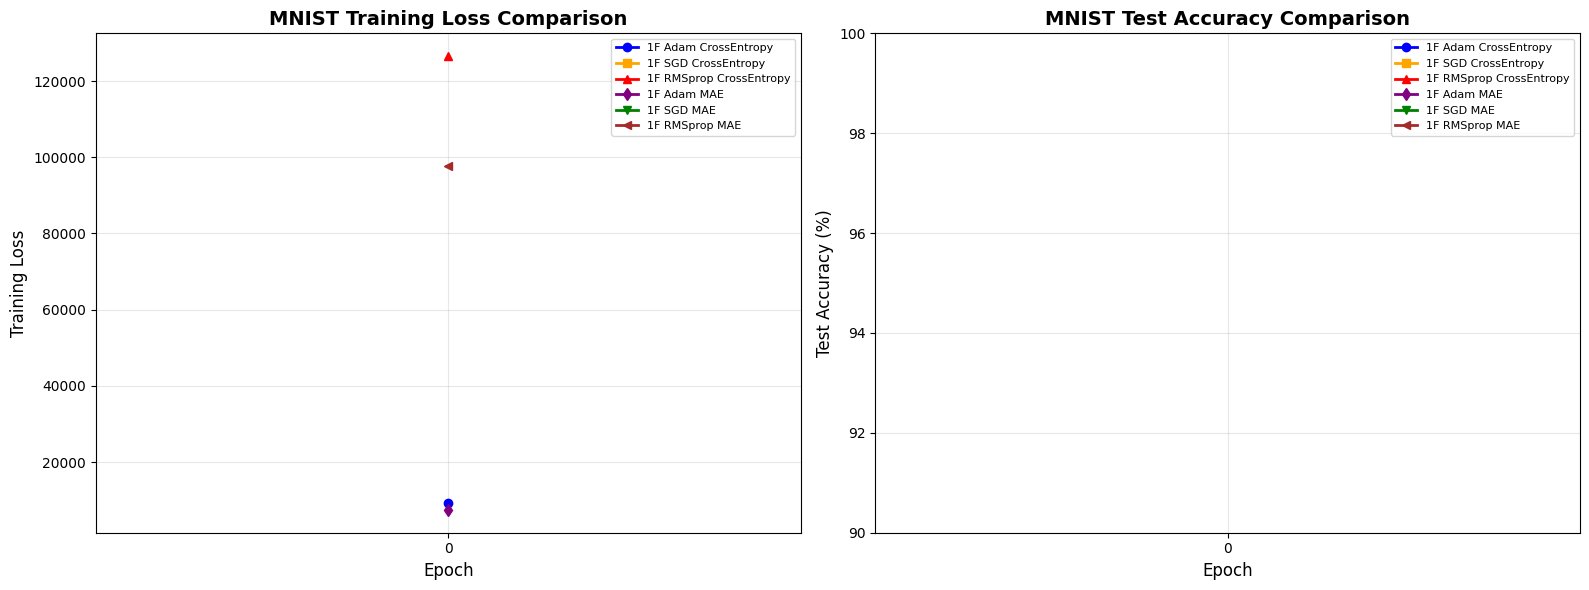


Final Test Accuracy Summary:
1F Adam CrossEntropy:          8.61%
1F SGD CrossEntropy:           9.80%
1F RMSprop CrossEntropy:       11.37%
1F Adam MAE:                   6.78%
1F SGD MAE:                    9.80%
1F RMSprop MAE:                10.10%


In [ ]:



class MNISTClassifier1F(nn.Module):
    def __init__(self):
        super().__init__()
        self.epsilon = EPSILON
        self.k_probes = K_PROBES
        self.energy = ENERGY
        self.num_classes = NUM_CLASSES
        self.batch_size = BATCH_SIZE

        v = torch.randn(self.batch_size, self.k_probes, self.k_probes)
        v = v / torch.norm(v, dim=1, keepdim=True)
        self.register_buffer('probes', v)

        resnet_model = models.resnet101(weights=None)
        resnet_model.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)

        self.model_upper1 = nn.Sequential(
            resnet_model.conv1,
            resnet_model.bn1,
            resnet_model.relu,
            resnet_model.maxpool,
        )
        self.model_upper2 = nn.Sequential(
            resnet_model.layer1,
            resnet_model.layer2,
        )
        # self.scalar_projection = nn.Sequential(
        #     nn.AdaptiveAvgPool2d((1, 1)),
        #     nn.Flatten(),
        #     nn.Linear(128, 1),
        # )
        self.model_lower1 = nn.Sequential(
            resnet_model.layer3,
            resnet_model.layer4,
        )
        self.conversion1 = nn.Linear(2048, 28*28, bias=False)
        self.conversion2 = nn.Sequential(
            nn.AdaptiveAvgPool2d((1,1)),   # [B,6,1,1]
            nn.Conv2d(6, 2048, kernel_size=1, bias=True)  # [B,2048,1,1]
        )
        self.model_lower2 = nn.Sequential(
            nn.AdaptiveAvgPool2d((1,1)),   # [B,6,1,1]
            nn.Flatten(),
            nn.Linear(2048, self.num_classes, bias=True),
        )


    def compute_score(self, h, x):
        if not x.requires_grad:
            x.requires_grad_(True)
        grads = torch.autograd.grad(
            outputs=h.sum(),
            inputs=x,
            create_graph=True, # Important for higher-order derivatives
            retain_graph=True
        )[0] # Shape: (Batch, d_in)

        scores = -torch.matmul(grads, self.probes)
        return scores

    def compute_local_fisher(self, x):
        e = self.model_upper1(x)
        h = self.model_upper2(e)

        """Computes I_psi(theta; x) at theta=0 (approx) via scores."""
        scores = self.compute_score(h, x)
        fisher_info = (scores ** 2).mean(dim=1, keepdim=True)
        return h, e, fisher_info

    def compute_fisher_on_output(self, h, x):
        """Compute Fisher information on a layer output with respect to input x."""
        scores = self.compute_score(h, x)
        fisher_info = (scores ** 2).mean(dim=1, keepdim=True)
        return fisher_info

    def forward(self, x):
        with torch.set_grad_enabled(True):
            if not x.requires_grad:
                x.requires_grad_(True)

            h, e, o0 = self.compute_local_fisher(x)
            mean_v = self.probes.mean(dim=0, keepdim=True)
            _, _, i_pos = self.compute_local_fisher(x + self.epsilon * mean_v)
            _, _, i_neg = self.compute_local_fisher(x - self.epsilon * mean_v)
            o1 = (i_pos - i_neg) / (2 * self.epsilon)
            o2 = (i_pos - 2 * o0 + i_neg) / (self.epsilon ** 2)

        # Compute Fisher information between conv_layer and pred_net
        with torch.set_grad_enabled(True):
            fisher_upper_net = self.compute_fisher_on_output(e, x)
        h = self.model_lower1(h)  # Output: [batch, 32, hidden_dim]

        with torch.set_grad_enabled(True):
            fisher_lower_net = self.compute_fisher_on_output(h, x)
        # h_ddash = h_dash.view(h_dash.size(0), -1)  # Flatten: [batch, 32*hidden_dim]
        h_dash = h.view(h.size(0), -1)          # [batch, 2048]
        # print(h.size(), h_dash.size())           ### torch.Size([512, 2048, 2, 2]) torch.Size([512, 4096])
        h_dash = self.conversion1(h_dash)                   # [batch, 8*28]
        h_dash = h_dash.view(-1, 1, 28, 28)            # [batch,1,28,28]

        features = torch.cat([h_dash, o0, o1, o2, fisher_upper_net, fisher_lower_net], dim=1)
        # print(h.size(), features.size())         ### torch.Size([512, 2048, 2, 2]) torch.Size([512, 6, 28, 28])
        features = self.conversion2(features)

        y_hat = self.model_lower2(features)

        return y_hat



if __name__ == "__main__":
    train_loader, test_loader = build_loaders(BATCH_SIZE, NUM_WORKERS)

    # For each model, create the model, create an optimizer bound to that model, then pass optimizer into run_experiment
    model = MNISTClassifier1F()
    optimizer = optim.Adam(model.parameters(), lr=LR)
    train_losses_1f_adam_crossentropy, test_accuracies_1f_adam_crossentropy = run_experiment(
        "ResNet101 1F (Adam + CrossEntropy)", model, train_loader, test_loader, optimizer=optimizer, use_jet=False
    )

    model = MNISTClassifier1F()
    optimizer = optim.SGD(model.parameters(), lr=LR)
    train_losses_1f_sgd_crossentropy, test_accuracies_1f_sgd_crossentropy = run_experiment(
        "ResNet101 1F (SGD + CrossEntropy)", model, train_loader, test_loader, optimizer=optimizer, use_jet=False
    )

    model = MNISTClassifier1F()
    optimizer = optim.RMSprop(model.parameters(), lr=LR)
    train_losses_1f_rmsprop_crossentropy, test_accuracies_1f_rmsprop_crossentropy = run_experiment(
        "ResNet101 1F (RMSprop + CrossEntropy)", model, train_loader, test_loader, optimizer=optimizer, use_jet=False
    )

    model = MNISTClassifier1F()
    optimizer = optim.Adam(model.parameters(), lr=LR)
    train_losses_1f_adam_mae, test_accuracies_1f_adam_mae = run_experiment(
        "ResNet101 1F (Adam + MAE)", model, train_loader, test_loader, optimizer=optimizer, loss_name='MAE', use_jet=False
    )

    model = MNISTClassifier1F()
    optimizer = optim.SGD(model.parameters(), lr=LR)
    train_losses_1f_sgd_mae, test_accuracies_1f_sgd_mae = run_experiment(
        "ResNet101 1F (SGD + MAE)", model, train_loader, test_loader, optimizer=optimizer, loss_name='MAE', use_jet=False
    )

    model = MNISTClassifier1F()
    optimizer = optim.RMSprop(model.parameters(), lr=LR)
    train_losses_1f_rmsprop_mae, test_accuracies_1f_rmsprop_mae = run_experiment(
        "ResNet101 1F (RMSprop + MAE)", model, train_loader, test_loader, optimizer=optimizer, loss_name='MAE', use_jet=False
    )


    print("\n--- Results Comparison ---")
    epochs = list(range(EPOCHS))
    results_df = pd.DataFrame({
        'Epoch': epochs,
        'Train_Loss_1F_Adam_CrossEntropy': train_losses_1f_adam_crossentropy,
        'Test_Accuracy_1F_Adam_CrossEntropy': test_accuracies_1f_adam_crossentropy,
        'Train_Loss_1F_SGD_CrossEntropy': train_losses_1f_sgd_crossentropy,
        'Test_Accuracy_1F_SGD_CrossEntropy': test_accuracies_1f_sgd_crossentropy,
        'Train_Loss_1F_RMSprop_CrossEntropy': train_losses_1f_rmsprop_crossentropy,
        'Test_Accuracy_1F_RMSprop_CrossEntropy': test_accuracies_1f_rmsprop_crossentropy,
        'Train_Loss_1F_Adam_MAE': train_losses_1f_adam_mae,
        'Test_Accuracy_1F_Adam_MAE': test_accuracies_1f_adam_mae,
        'Train_Loss_1F_SGD_MAE': train_losses_1f_sgd_mae,
        'Test_Accuracy_1F_SGD_MAE': test_accuracies_1f_sgd_mae,
        'Train_Loss_1F_RMSprop_MAE': train_losses_1f_rmsprop_mae,
        'Test_Accuracy_1F_RMSprop_MAE': test_accuracies_1f_rmsprop_mae,
    })

    csv_filename = 'training_results_resnet101_mnist.csv'
    results_df.to_csv(csv_filename, index=False)
    print(f"Results saved to {csv_filename}")
    print("\nDataFrame Preview:")
    print(results_df)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    for loss, label, marker, color in [
        (train_losses_1f_adam_crossentropy, '1F Adam CrossEntropy', 'o', 'blue'),
        (train_losses_1f_sgd_crossentropy, '1F SGD CrossEntropy', 's', 'orange'),
        (train_losses_1f_rmsprop_crossentropy, '1F RMSprop CrossEntropy', '^', 'red'),
        (train_losses_1f_adam_mae, '1F Adam MAE', 'd', 'purple'),
        (train_losses_1f_sgd_mae, '1F SGD MAE', 'v', 'green'),
        (train_losses_1f_rmsprop_mae, '1F RMSprop MAE', '<', 'brown'),
    ]:
        ax1.plot(epochs, loss, marker=marker, linewidth=2, markersize=6, label=label, color=color)

    for acc, label, marker, color in [
        (test_accuracies_1f_adam_crossentropy, '1F Adam CrossEntropy', 'o', 'blue'),
        (test_accuracies_1f_sgd_crossentropy, '1F SGD CrossEntropy', 's', 'orange'),
        (test_accuracies_1f_rmsprop_crossentropy, '1F RMSprop CrossEntropy', '^', 'red'),
        (test_accuracies_1f_adam_mae, '1F Adam MAE', 'd', 'purple'),
        (test_accuracies_1f_sgd_mae, '1F SGD MAE', 'v', 'green'),
        (test_accuracies_1f_rmsprop_mae, '1F RMSprop MAE', '<', 'brown'),
    ]:
        ax2.plot(epochs, acc, marker=marker, linewidth=2, markersize=6, label=label, color=color)

    ax1.set_xlabel('Epoch', fontsize=12)
    ax1.set_ylabel('Training Loss', fontsize=12)
    ax1.set_title('MNIST Training Loss Comparison', fontsize=14, fontweight='bold')
    ax1.legend(fontsize=8)
    ax1.grid(True, alpha=0.3)
    ax1.set_xticks(epochs)

    ax2.set_xlabel('Epoch', fontsize=12)
    ax2.set_ylabel('Test Accuracy (%)', fontsize=12)
    ax2.set_title('MNIST Test Accuracy Comparison', fontsize=14, fontweight='bold')
    ax2.legend(fontsize=8)
    ax2.grid(True, alpha=0.3)
    ax2.set_xticks(epochs)
    ax2.set_ylim([90, 100])

    plt.tight_layout()
    plt.savefig('training_results_resnet101_mnist_1F.png', dpi=150, bbox_inches='tight')
    print("\nComparison plot saved as 'training_results_resnet101_mnist_1F.png'")
    plt.show()

    print("\n" + "=" * 60)
    print("Final Test Accuracy Summary:")
    print("=" * 60)
    print(f"1F Adam CrossEntropy:          {test_accuracies_1f_adam_crossentropy[-1]:.2f}%")
    print(f"1F SGD CrossEntropy:           {test_accuracies_1f_sgd_crossentropy[-1]:.2f}%")
    print(f"1F RMSprop CrossEntropy:       {test_accuracies_1f_rmsprop_crossentropy[-1]:.2f}%")
    print(f"1F Adam MAE:                   {test_accuracies_1f_adam_mae[-1]:.2f}%")
    print(f"1F SGD MAE:                    {test_accuracies_1f_sgd_mae[-1]:.2f}%")
    print(f"1F RMSprop MAE:                {test_accuracies_1f_rmsprop_mae[-1]:.2f}%")
    print("=" * 60)


In [ ]:



if __name__ == "__main__":
    train_loader, test_loader = build_loaders(BATCH_SIZE, NUM_WORKERS)

    # For each model, create the model, create an optimizer bound to that model, then pass optimizer into run_experiment
    model = MNISTClassifier1F(NUM_CLASSES, K_PROBES, EPSILON, ENERGY)
    optimizer = optim.Adam(model.parameters(), lr=LR)
    train_losses_1f_adam_crossentropy, test_accuracies_1f_adam_crossentropy = run_experiment(
        "ResNet101 1F (Adam + CrossEntropy)", model, train_loader, test_loader, optimizer=optimizer, use_jet=False
    )

    model = MNISTClassifier1F(NUM_CLASSES, K_PROBES, EPSILON, ENERGY)
    optimizer = optim.SGD(model.parameters(), lr=LR)
    train_losses_1f_sgd_crossentropy, test_accuracies_1f_sgd_crossentropy = run_experiment(
        "ResNet101 1F (SGD + CrossEntropy)", model, train_loader, test_loader, optimizer=optimizer, use_jet=False
    )

    model = MNISTClassifier1F(NUM_CLASSES, K_PROBES, EPSILON, ENERGY)
    optimizer = optim.RMSprop(model.parameters(), lr=LR)
    train_losses_1f_rmsprop_crossentropy, test_accuracies_1f_rmsprop_crossentropy = run_experiment(
        "ResNet101 1F (RMSprop + CrossEntropy)", model, train_loader, test_loader, optimizer=optimizer, use_jet=False
    )

    model = MNISTClassifier1F(NUM_CLASSES, K_PROBES, EPSILON, ENERGY)
    optimizer = optim.Adam(model.parameters(), lr=LR)
    train_losses_1f_adam_mae, test_accuracies_1f_adam_mae = run_experiment(
        "ResNet101 1F (Adam + MAE)", model, train_loader, test_loader, optimizer=optimizer, loss_name='MAE', use_jet=False
    )

    model = MNISTClassifier1F(NUM_CLASSES, K_PROBES, EPSILON, ENERGY)
    optimizer = optim.SGD(model.parameters(), lr=LR)
    train_losses_1f_sgd_mae, test_accuracies_1f_sgd_mae = run_experiment(
        "ResNet101 1F (SGD + MAE)", model, train_loader, test_loader, optimizer=optimizer, loss_name='MAE', use_jet=False
    )

    model = MNISTClassifier1F(NUM_CLASSES, K_PROBES, EPSILON, ENERGY)
    optimizer = optim.RMSprop(model.parameters(), lr=LR)
    train_losses_1f_rmsprop_mae, test_accuracies_1f_rmsprop_mae = run_experiment(
        "ResNet101 1F (RMSprop + MAE)", model, train_loader, test_loader, optimizer=optimizer, loss_name='MAE', use_jet=False
    )


    print("\n--- Results Comparison ---")
    epochs = list(range(EPOCHS))
    results_df = pd.DataFrame({
        'Epoch': epochs,
        'Train_Loss_1F_Adam_CrossEntropy': train_losses_1f_adam_crossentropy,
        'Test_Accuracy_1F_Adam_CrossEntropy': test_accuracies_1f_adam_crossentropy,
        'Train_Loss_1F_SGD_CrossEntropy': train_losses_1f_sgd_crossentropy,
        'Test_Accuracy_1F_SGD_CrossEntropy': test_accuracies_1f_sgd_crossentropy,
        'Train_Loss_1F_RMSprop_CrossEntropy': train_losses_1f_rmsprop_crossentropy,
        'Test_Accuracy_1F_RMSprop_CrossEntropy': test_accuracies_1f_rmsprop_crossentropy,
        'Train_Loss_1F_Adam_MAE': train_losses_1f_adam_mae,
        'Test_Accuracy_1F_Adam_MAE': test_accuracies_1f_adam_mae,
        'Train_Loss_1F_SGD_MAE': train_losses_1f_sgd_mae,
        'Test_Accuracy_1F_SGD_MAE': test_accuracies_1f_sgd_mae,
        'Train_Loss_1F_RMSprop_MAE': train_losses_1f_rmsprop_mae,
        'Test_Accuracy_1F_RMSprop_MAE': test_accuracies_1f_rmsprop_mae,
    })

    csv_filename = 'training_results_resnet101_mnist.csv'
    results_df.to_csv(csv_filename, index=False)
    print(f"Results saved to {csv_filename}")
    print("\nDataFrame Preview:")
    print(results_df)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    for loss, label, marker, color in [
        (train_losses_1f_adam_crossentropy, '1F Adam CrossEntropy', 'o', 'blue'),
        (train_losses_1f_sgd_crossentropy, '1F SGD CrossEntropy', 's', 'orange'),
        (train_losses_1f_rmsprop_crossentropy, '1F RMSprop CrossEntropy', '^', 'red'),
        (train_losses_1f_adam_mae, '1F Adam MAE', 'd', 'purple'),
        (train_losses_1f_sgd_mae, '1F SGD MAE', 'v', 'green'),
        (train_losses_1f_rmsprop_mae, '1F RMSprop MAE', '<', 'brown'),
    ]:
        ax1.plot(epochs, loss, marker=marker, linewidth=2, markersize=6, label=label, color=color)

    for acc, label, marker, color in [
        (test_accuracies_1f_adam_crossentropy, '1F Adam CrossEntropy', 'o', 'blue'),
        (test_accuracies_1f_sgd_crossentropy, '1F SGD CrossEntropy', 's', 'orange'),
        (test_accuracies_1f_rmsprop_crossentropy, '1F RMSprop CrossEntropy', '^', 'red'),
        (test_accuracies_1f_adam_mae, '1F Adam MAE', 'd', 'purple'),
        (test_accuracies_1f_sgd_mae, '1F SGD MAE', 'v', 'green'),
        (test_accuracies_1f_rmsprop_mae, '1F RMSprop MAE', '<', 'brown'),
    ]:
        ax2.plot(epochs, acc, marker=marker, linewidth=2, markersize=6, label=label, color=color)

    ax1.set_xlabel('Epoch', fontsize=12)
    ax1.set_ylabel('Training Loss', fontsize=12)
    ax1.set_title('MNIST Training Loss Comparison', fontsize=14, fontweight='bold')
    ax1.legend(fontsize=8)
    ax1.grid(True, alpha=0.3)
    ax1.set_xticks(epochs)

    ax2.set_xlabel('Epoch', fontsize=12)
    ax2.set_ylabel('Test Accuracy (%)', fontsize=12)
    ax2.set_title('MNIST Test Accuracy Comparison', fontsize=14, fontweight='bold')
    ax2.legend(fontsize=8)
    ax2.grid(True, alpha=0.3)
    ax2.set_xticks(epochs)
    ax2.set_ylim([90, 100])

    plt.tight_layout()
    plt.savefig('training_results_resnet101_mnist_1F.png', dpi=150, bbox_inches='tight')
    print("\nComparison plot saved as 'training_results_resnet101_mnist_1F.png'")
    plt.show()

    print("\n" + "=" * 60)
    print("Final Test Accuracy Summary:")
    print("=" * 60)
    print(f"1F Adam CrossEntropy:          {test_accuracies_1f_adam_crossentropy[-1]:.2f}%")
    print(f"1F SGD CrossEntropy:           {test_accuracies_1f_sgd_crossentropy[-1]:.2f}%")
    print(f"1F RMSprop CrossEntropy:       {test_accuracies_1f_rmsprop_crossentropy[-1]:.2f}%")
    print(f"1F Adam MAE:                   {test_accuracies_1f_adam_mae[-1]:.2f}%")
    print(f"1F SGD MAE:                    {test_accuracies_1f_sgd_mae[-1]:.2f}%")
    print(f"1F RMSprop MAE:                {test_accuracies_1f_rmsprop_mae[-1]:.2f}%")
    print("=" * 60)



Loading MNIST dataset...
Train samples: 60000, Test samples: 10000


TypeError: MNISTClassifier1F.__init__() takes 1 positional argument but 5 were given

In [ ]:



if __name__ == "__main__":
    train_loader, test_loader = build_loaders(BATCH_SIZE, NUM_WORKERS)

    # For each model, create the model, create an optimizer bound to that model, then pass optimizer into run_experiment
    model = baseline_resnet101(NUM_CLASSES)
    optimizer = optim.Adam(model.parameters(), lr=LR)
    train_losses_baseline, test_accuracies_baseline = run_experiment(
        "Baseline ResNet101 (Adam)", model, train_loader, test_loader, optimizer=optimizer, use_jet=False, log_every=150
    )

    model = MNISTClassifier1F(NUM_CLASSES, K_PROBES, EPSILON)
    optimizer = optim.Adam(model.parameters(), lr=LR)
    train_losses_no_jet_1f, test_accuracies_no_jet_1f = run_experiment(
        "QI ResNet101 without Jet Loss 1F (Adam)", model, train_loader, test_loader, optimizer=optimizer, use_jet=False
    )

    model = MNISTClassifier1F(NUM_CLASSES, K_PROBES, EPSILON)
    optimizer = optim.Adam(model.parameters(), lr=LR)
    train_losses_jet_1f, test_accuracies_jet_1f = run_experiment(
        "QI ResNet101 with Jet Loss 1F (Adam)", model, train_loader, test_loader, optimizer=optimizer, use_jet=True
    )

    model = MNISTClassifier2F(NUM_CLASSES, K_PROBES, EPSILON)
    optimizer = optim.Adam(model.parameters(), lr=LR)
    train_losses_no_jet_2f, test_accuracies_no_jet_2f = run_experiment(
        "QI ResNet101 without Jet Loss 2F (Adam)", model, train_loader, test_loader, optimizer=optimizer, use_jet=False
    )

    model = MNISTClassifier2F(NUM_CLASSES, K_PROBES, EPSILON)
    optimizer = optim.Adam(model.parameters(), lr=LR)
    train_losses_jet_2f, test_accuracies_jet_2f = run_experiment(
        "QI ResNet101 with Jet Loss 2F (Adam)", model, train_loader, test_loader, optimizer=optimizer, use_jet=True
    )

    model = MNISTClassifier3F(NUM_CLASSES, K_PROBES, EPSILON)
    optimizer = optim.Adam(model.parameters(), lr=LR)
    train_losses_no_jet_3f, test_accuracies_no_jet_3f = run_experiment(
        "QI ResNet101 without Jet Loss 3F (Adam)", model, train_loader, test_loader, optimizer=optimizer, use_jet=False
    )

    model = MNISTClassifier3F(NUM_CLASSES, K_PROBES, EPSILON)
    optimizer = optim.Adam(model.parameters(), lr=LR)
    train_losses_jet_3f, test_accuracies_jet_3f = run_experiment(
        "QI ResNet101 with Jet Loss 3F (Adam)", model, train_loader, test_loader, optimizer=optimizer, use_jet=True
    )

    model = MNISTClassifierAllF(NUM_CLASSES)
    optimizer = optim.Adam(model.parameters(), lr=LR)
    train_losses_no_jet_allf, test_accuracies_no_jet_allf = run_experiment(
        "QI ResNet101 with Fisher from Every Layer (no Jet, Adam)", model, train_loader, test_loader, optimizer=optimizer, use_jet=False, log_every=150
    )

    model = MNISTClassifierAllF(NUM_CLASSES)
    optimizer = optim.Adam(model.parameters(), lr=LR)
    train_losses_jet_allf, test_accuracies_jet_allf = run_experiment(
        "QI ResNet101 with Fisher from Every Layer (Jet, Adam)", model, train_loader, test_loader, optimizer=optimizer, use_jet=True, log_every=150
    )

    # Example additional runs with different optimizers for baseline model
    model = baseline_resnet101(NUM_CLASSES)
    optimizer = optim.SGD(model.parameters(), lr=LR)
    train_losses_sgd, test_accuracies_sgd = run_experiment(
        "Baseline ResNet101 (SGD)", model, train_loader, test_loader, optimizer=optimizer, use_jet=False, log_every=150
    )

    model = baseline_resnet101(NUM_CLASSES)
    optimizer = optim.RMSprop(model.parameters(), lr=LR)
    train_losses_rmsprop, test_accuracies_rmsprop = run_experiment(
        "Baseline ResNet101 (RMSprop)", model, train_loader, test_loader, optimizer=optimizer, use_jet=False, log_every=150
    )

    model = baseline_resnet101(NUM_CLASSES)
    optimizer = optim.Adam(model.parameters(), lr=LR)
    train_losses_mae, test_accuracies_mae = run_experiment(
        "Baseline ResNet101 (Adam + MAE)", model, train_loader, test_loader, optimizer=optimizer, loss_name='MAE', use_jet=False, log_every=150
    )

    print("\n--- Results Comparison ---")
    epochs = list(range(EPOCHS))
    results_df = pd.DataFrame({
        'Epoch': epochs,
        'Baseline_Train_Loss': train_losses_baseline,
        'Baseline_Test_Accuracy': test_accuracies_baseline,
        'No_Jet_Train_Loss_1F': train_losses_no_jet_1f,
        'No_Jet_Test_Accuracy_1F': test_accuracies_no_jet_1f,
        'Jet_Train_Loss_1F': train_losses_jet_1f,
        'Jet_Test_Accuracy_1F': test_accuracies_jet_1f,
        'No_Jet_Train_Loss_2F': train_losses_no_jet_2f,
        'No_Jet_Test_Accuracy_2F': test_accuracies_no_jet_2f,
        'Jet_Train_Loss_2F': train_losses_jet_2f,
        'Jet_Test_Accuracy_2F': test_accuracies_jet_2f,
        'No_Jet_Train_Loss_3F': train_losses_no_jet_3f,
        'No_Jet_Test_Accuracy_3F': test_accuracies_no_jet_3f,
        'Jet_Train_Loss_3F': train_losses_jet_3f,
        'Jet_Test_Accuracy_3F': test_accuracies_jet_3f,
        'No_Jet_AllF_Train_Loss': train_losses_no_jet_allf,
        'No_Jet_AllF_Test_Accuracy': test_accuracies_no_jet_allf,
        'Jet_AllF_Train_Loss': train_losses_jet_allf,
        'Jet_AllF_Test_Accuracy': test_accuracies_jet_allf,
        'SGD_Train_Loss': train_losses_sgd,
        'SGD_Test_Accuracy': test_accuracies_sgd,
        'RMSprop_Train_Loss': train_losses_rmsprop,
        'RMSprop_Test_Accuracy': test_accuracies_rmsprop,
        'MAE_Train_Loss': train_losses_mae,
        'MAE_Test_Accuracy': test_accuracies_mae,
    })

    csv_filename = 'training_results_resnet101_mnist.csv'
    results_df.to_csv(csv_filename, index=False)
    print(f"Results saved to {csv_filename}")
    print("\nDataFrame Preview:")
    print(results_df)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    for loss, label, marker, color in [
        (train_losses_baseline, 'Baseline ResNet101', 'o', 'blue'),
        (train_losses_no_jet_1f, 'QI no Jet 1F', 's', 'orange'),
        (train_losses_jet_1f, 'QI with Jet 1F', '^', 'red'),
        (train_losses_no_jet_2f, 'QI no Jet 2F', 'd', 'purple'),
        (train_losses_jet_2f, 'QI with Jet 2F', 'v', 'green'),
        (train_losses_no_jet_3f, 'QI no Jet 3F', '<', 'brown'),
        (train_losses_jet_3f, 'QI with Jet 3F', '>', 'pink'),
        (train_losses_no_jet_allf, 'QI no Jet AllF', 'x', 'black'),
        (train_losses_jet_allf, 'QI with Jet AllF', '+', 'cyan'),
        (train_losses_sgd, 'Baseline SGD', 'D', 'magenta'),
        (train_losses_rmsprop, 'Baseline RMSprop', 'P', 'green'),
        (train_losses_mae, 'Baseline MAE', 'X', 'red'),
    ]:
        ax1.plot(epochs, loss, marker=marker, linewidth=2, markersize=6, label=label, color=color)

    for acc, label, marker, color in [
        (test_accuracies_baseline, 'Baseline ResNet101', 'o', 'blue'),
        (test_accuracies_no_jet_1f, 'QI no Jet 1F', 's', 'orange'),
        (test_accuracies_jet_1f, 'QI with Jet 1F', '^', 'red'),
        (test_accuracies_no_jet_2f, 'QI no Jet 2F', 'd', 'purple'),
        (test_accuracies_jet_2f, 'QI with Jet 2F', 'v', 'green'),
        (test_accuracies_no_jet_3f, 'QI no Jet 3F', '<', 'brown'),
        (test_accuracies_jet_3f, 'QI with Jet 3F', '>', 'pink'),
        (test_accuracies_no_jet_allf, 'QI no Jet AllF', 'x', 'black'),
        (test_accuracies_jet_allf, 'QI with Jet AllF', '+', 'cyan'),
        (test_accuracies_sgd, 'Baseline SGD', 'D', 'magenta'),
        (test_accuracies_rmsprop, 'Baseline RMSprop', 'P', 'green'),
        (test_accuracies_mae, 'Baseline MAE', 'X', 'red'),
    ]:
        ax2.plot(epochs, acc, marker=marker, linewidth=2, markersize=6, label=label, color=color)

    ax1.set_xlabel('Epoch', fontsize=12)
    ax1.set_ylabel('Training Loss', fontsize=12)
    ax1.set_title('MNIST Training Loss Comparison', fontsize=14, fontweight='bold')
    ax1.legend(fontsize=8)
    ax1.grid(True, alpha=0.3)
    ax1.set_xticks(epochs)

    ax2.set_xlabel('Epoch', fontsize=12)
    ax2.set_ylabel('Test Accuracy (%)', fontsize=12)
    ax2.set_title('MNIST Test Accuracy Comparison', fontsize=14, fontweight='bold')
    ax2.legend(fontsize=8)
    ax2.grid(True, alpha=0.3)
    ax2.set_xticks(epochs)
    ax2.set_ylim([90, 100])

    plt.tight_layout()
    plt.savefig('training_results_resnet101_mnist.png', dpi=150, bbox_inches='tight')
    print("\nComparison plot saved as 'training_results_resnet101_mnist.png'")
    plt.show()

    print("\n" + "=" * 60)
    print("Final Test Accuracy Summary:")
    print("=" * 60)
    print(f"Baseline ResNet101:          {test_accuracies_baseline[-1]:.2f}%")
    print(f"QI without Jet Loss 1F:     {test_accuracies_no_jet_1f[-1]:.2f}%")
    print(f"QI with Jet Loss 1F:        {test_accuracies_jet_1f[-1]:.2f}%")
    print(f"QI without Jet Loss 2F:     {test_accuracies_no_jet_2f[-1]:.2f}%")
    print(f"QI with Jet Loss 2F:        {test_accuracies_jet_2f[-1]:.2f}%")
    print(f"QI without Jet Loss 3F:     {test_accuracies_no_jet_3f[-1]:.2f}%")
    print(f"QI with Jet Loss 3F:        {test_accuracies_jet_3f[-1]:.2f}%")
    print(f"QI without Jet Loss AllF:   {test_accuracies_no_jet_allf[-1]:.2f}%")
    print(f"QI with Jet Loss AllF:      {test_accuracies_jet_allf[-1]:.2f}%")
    print("=" * 60)

